In [3]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

radiomics_features_dir = Path("/mnt/l/Basic/divi/jstoker/slicer_pdac/Marius/Reza Morphology/data/preprocessed_data/CRLM/05_radiomics_features")
excel_sheet_path = Path("/mnt/l/Basic/divi/jstoker/slicer_pdac/Marius/Reza Morphology/data/preprocessed_data/CRLM/dataset_CAESAR_dec23_MASTER.xlsx")

# Load the Excel sheet
excel_sheet = pd.read_excel(excel_sheet_path)

def read_csv(csv_path):
    df = pd.read_csv(csv_path)
    return df

def get_ttv_from_radiomics_features(radiomics_features_dir, excel_sheet):
    radiomics_csv_files = list(radiomics_features_dir.glob("*.csv"))
    for csv_file in tqdm(radiomics_csv_files, desc="Processing radiomics CSV files"):
        df = read_csv(csv_file)
        # Extract patient ID from the filename (assuming format "patientID_radiomics.csv")
        patient_id = int(csv_file.stem.split("_")[0][-3:])
        image_id = int(csv_file.stem.split("_")[1])
        # Get TTV from the Excel sheet using patient ID
        ttv_value = sum(df['lesion_volume_mm3'].values)
        # add to excel sheet
        if image_id == 0:
            excel_sheet.loc[excel_sheet['SubjectKey'] == patient_id, 'TTV_base'] = ttv_value
        else:
            excel_sheet.loc[excel_sheet['SubjectKey'] == patient_id, f'TTV_followup_{image_id}'] = ttv_value
    return excel_sheet  

excel_sheet = pd.read_excel(excel_sheet_path)
updated_excel_sheet = get_ttv_from_radiomics_features(radiomics_features_dir, excel_sheet)

Processing radiomics CSV files: 100%|██████████| 997/997 [01:44<00:00,  9.56it/s]


In [ ]:
# calculte ttv change and add to excel sheet
for index, row in updated_excel_sheet.iterrows():
    ttv_base = row['TTV_base']
    for image_id in range(1, 4):  # Assuming there are up to 3 follow-up images
        ttv_followup = row.get(f'TTV_followup_{image_id}', np.nan)
        if pd.notna(ttv_followup) and pd.notna(ttv_base):
            ttv_change = (ttv_followup - ttv_base) / ttv_base * 100
            updated_excel_sheet.loc[index, f'TTV_change_{image_id}'] = ttv_change

In [11]:
filtered_by_segmentation = updated_excel_sheet[updated_excel_sheet['Segmented'] == 'Yes']
# save updated excel sheet
updated_excel_sheet.to_excel("./crlm_ttv.xlsx", index=False)

OSm Positive (ER=1) count: 133, mean: -7.903053615564064, std: 11.565657585380784
OSm Negative (ER=0) count: 285, mean: -9.14070532734408, std: 16.338113044388628


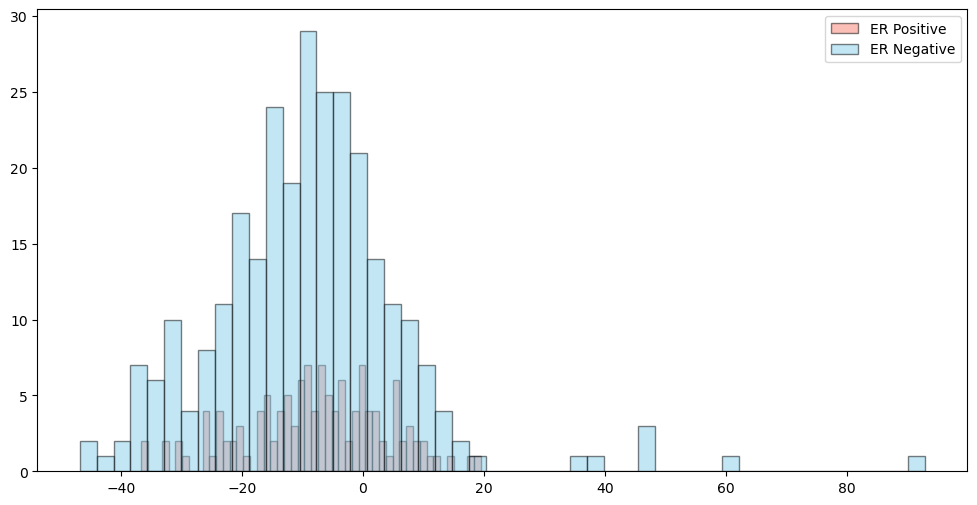

In [29]:
import matplotlib.pyplot as plt

# show two histograms on top for OSm and labels ER column (0-1) with different colors
ER_positive = filtered_by_segmentation[filtered_by_segmentation['ER (1 = yes, 0 = no)'] == 1]['TTV_change_1']
ER_negative = filtered_by_segmentation[filtered_by_segmentation['ER (1 = yes, 0 = no)'] == 0]['TTV_change_1']
print(f"OSm Positive (ER=1) count: {len(ER_positive)}, mean: {ER_positive.mean()}, std: {ER_positive.std()}")
print(f"OSm Negative (ER=0) count: {len(ER_negative)}, mean: {ER_negative.mean()}, std: {ER_negative.std()}")
plt.figure(figsize=(12, 6))
plt.hist(ER_positive, bins=50, color='salmon', edgecolor='black', alpha=0.5, label='ER Positive')
plt.hist(ER_negative, bins=50, color='skyblue', edgecolor='black', alpha=0.5, label='ER Negative')
plt.legend()
plt.show()


OSm Positive (>=24) count: 246, mean: -9.696232905961626, std: 12.76924277976265
OSm Negative (<24) count: 172, mean: -7.379467683680595, std: 17.669819865617235


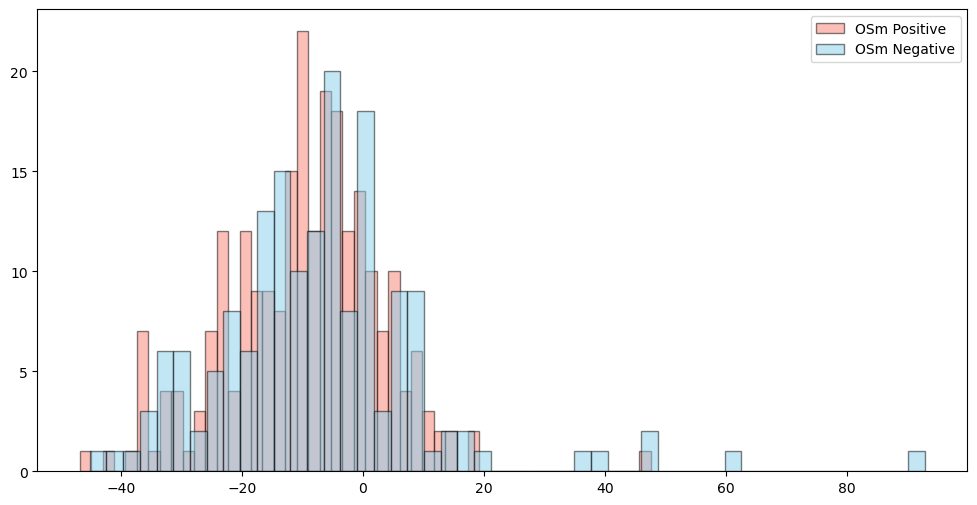

In [30]:
import matplotlib.pyplot as plt

# show two histograms on top for OSm and labels ER column (0-1) with different colors
ER_positive_osm = filtered_by_segmentation[filtered_by_segmentation['OSm']>=24]['TTV_change_1']
ER_negative_osm = filtered_by_segmentation[filtered_by_segmentation['OSm'] < 24]['TTV_change_1']
print(f"OSm Positive (>=24) count: {len(ER_positive_osm)}, mean: {ER_positive_osm.mean()}, std: {ER_positive_osm.std()}")
print(f"OSm Negative (<24) count: {len(ER_negative_osm)}, mean: {ER_negative_osm.mean()}, std: {ER_negative_osm.std()}")
plt.figure(figsize=(12, 6))
plt.hist(ER_positive_osm, bins=50, color='salmon', edgecolor='black', alpha=0.5, label='OSm Positive')
plt.hist(ER_negative_osm, bins=50, color='skyblue', edgecolor='black', alpha=0.5, label='OSm Negative')
plt.legend()
plt.show()


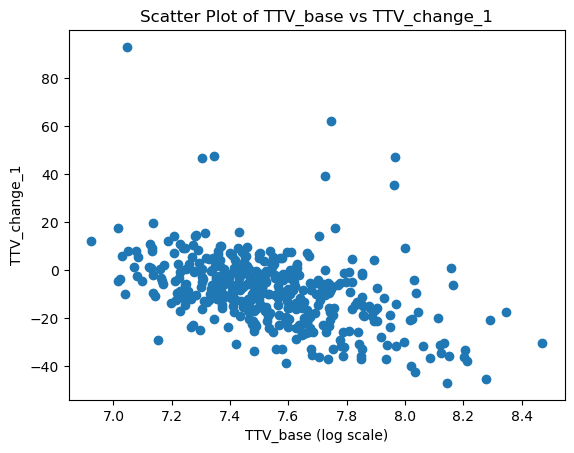

In [27]:
# filtered_by_segmentation['TTV_change_1']
# filtered_by_segmentation['TTV_base']

plt.scatter(np.log(filtered_by_segmentation['TTV_base']/1000), filtered_by_segmentation['TTV_change_1'])
plt.xlabel('TTV_base (log scale)')
plt.ylabel('TTV_change_1')
plt.title('Scatter Plot of TTV_base vs TTV_change_1')
plt.show()

In [21]:
filtered_by_segmentation['TTV_base'].describe()

count    4.130000e+02
mean     1.958076e+06
std      5.562044e+05
min      1.016470e+06
25%      1.583925e+06
50%      1.826451e+06
75%      2.213583e+06
max      4.773819e+06
Name: TTV_base, dtype: float64